In [1]:
# Importing required libraries for data handling and visualization
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# To display all columns clearly
pd.set_option('display.max_columns',None)

In [2]:
#Loading the training dataset
train = pd.read_csv("datasets/train.csv")

#Loading the testing dataset
test = pd.read_csv("datasets/test.csv")

In [3]:
#Checking no. of rows and columns
print("Training data shape:",train.shape)
print("Testing data shape:",test.shape)

Training data shape: (48120, 4)
Testing data shape: (11808, 3)


In [5]:
# Displaying first few rows of training data
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [6]:
# Displaying first few rows of testing data
test.head()

,DateTime,Junction,ID
0,2017-07-01 00:00:00,1,20170701001
1,2017-07-01 01:00:00,1,20170701011
2,2017-07-01 02:00:00,1,20170701021
3,2017-07-01 03:00:00,1,20170701031
4,2017-07-01 04:00:00,1,20170701041


In [13]:
# Listing columns in training dataset
train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

In [14]:
# Listing columns in testing dataset
test.columns

Index(['DateTime', 'Junction', 'ID'], dtype='object')

In [15]:
# Checking data types and missing values in training dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [16]:
# Checking data types and missing values in testing dataset
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  11808 non-null  object
 1   Junction  11808 non-null  int64 
 2   ID        11808 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 276.9+ KB


In [18]:
#The training dataset contains the target variable Vehicles, which represents traffic volume at each junction. 
#The testing dataset does not include this column, indicating that the task is to forecast future traffic values based on historical data.

In [19]:
#Convert DataTime colums to datetime format
train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime'] = pd.to_datetime(test['DateTime'])

In [20]:
# Sorting datasets by DateTime for proper time series analysis
train = train.sort_values('DateTime')
test = test.sort_values('DateTime')

In [21]:
#Statistical summary of traffic volume
train.describe()

,DateTime,Junction,Vehicles,ID
count,48120,48120.000000,48120.000000,4.812000e+04
mean,2016-09-19 06:03:56.109725696,2.180549,22.791334,2.016330e+10
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10
std,NaN,0.966955,20.750063,5.944854e+06


In [22]:
#Checking unique junctions
train['Junction'].unique()

array([1, 2, 3, 4])

In [23]:
#Count of records per junction
train['Junction'].value_counts()

Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

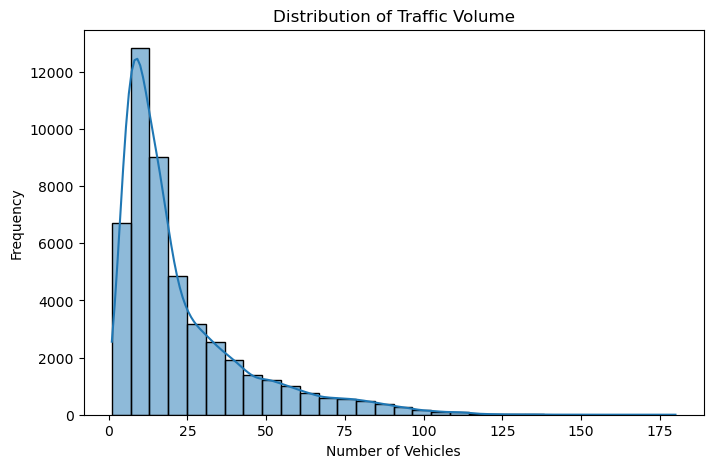

In [24]:
# Distribution of traffic volume
plt.figure(figsize=(8,5))
sns.histplot(train['Vehicles'], bins=30, kde=True)
plt.title("Distribution of Traffic Volume")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")
plt.show()

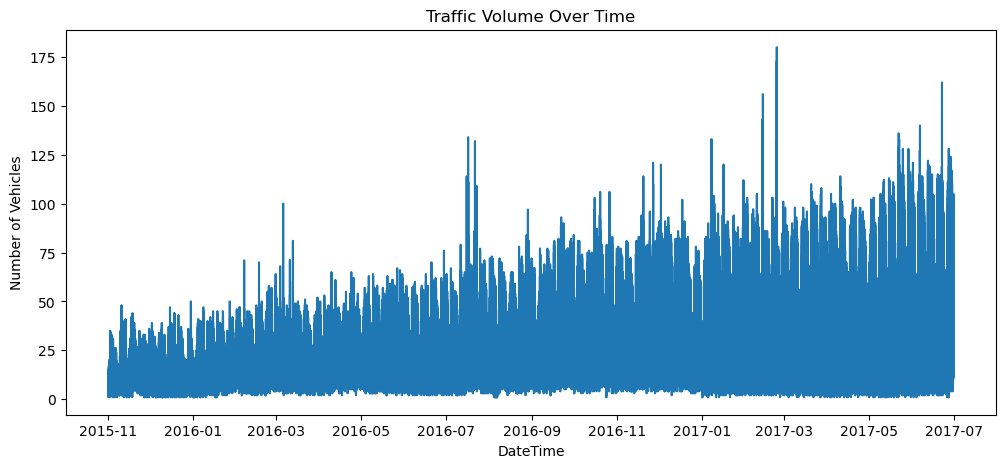

In [25]:
# Traffic trend over time
plt.figure(figsize=(12,5))
plt.plot(train['DateTime'], train['Vehicles'])
plt.title("Traffic Volume Over Time")
plt.xlabel("DateTime")
plt.ylabel("Number of Vehicles")
plt.show()

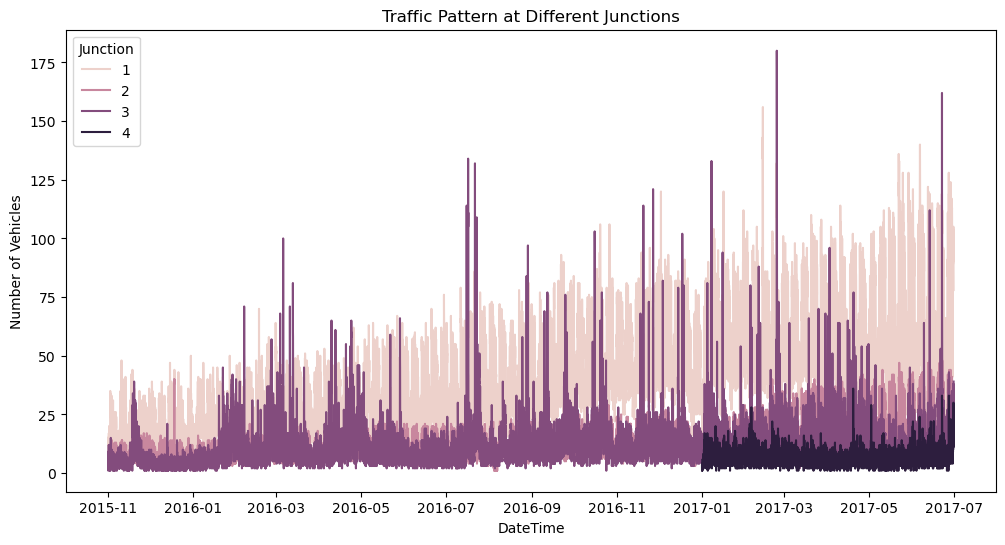

In [26]:
# Traffic trends for each junction
plt.figure(figsize=(12,6))
sns.lineplot(data=train, x='DateTime', y='Vehicles', hue='Junction')
plt.title("Traffic Pattern at Different Junctions")
plt.xlabel("DateTime")
plt.ylabel("Number of Vehicles")
plt.show()

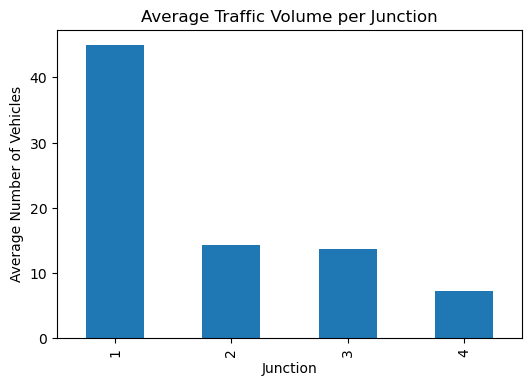

In [27]:
# Average traffic volume per junction
avg_traffic = train.groupby('Junction')['Vehicles'].mean()

avg_traffic.plot(kind='bar', figsize=(6,4), title="Average Traffic Volume per Junction")
plt.xlabel("Junction")
plt.ylabel("Average Number of Vehicles")
plt.show()

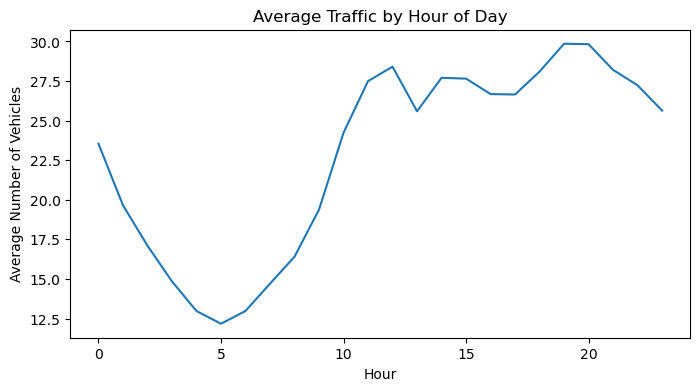

In [30]:
# Extracting hour from DateTime
train['Hour'] = train['DateTime'].dt.hour

# Average traffic per hour
hourly_traffic = train.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize=(8,4))
hourly_traffic.plot()
plt.title("Average Traffic by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Number of Vehicles")
plt.show()

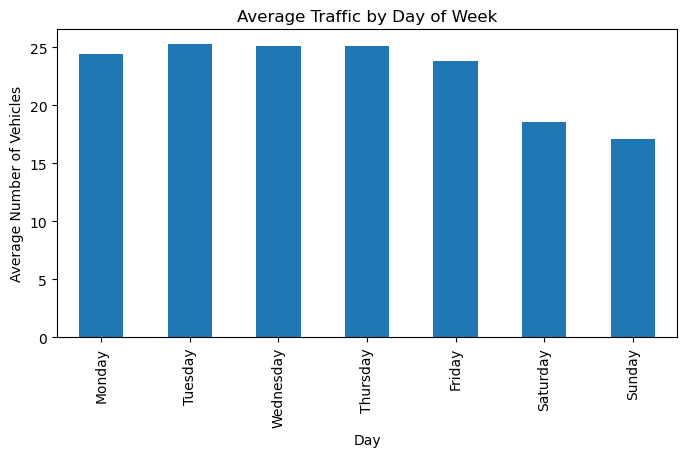

In [31]:
# Extracting day of week
train['DayOfWeek'] = train['DateTime'].dt.day_name()

# Average traffic by day
day_traffic = train.groupby('DayOfWeek')['Vehicles'].mean()

day_traffic = day_traffic.reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(8,4))
day_traffic.plot(kind='bar')
plt.title("Average Traffic by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Number of Vehicles")
plt.show()

In [32]:
# Extracting hour of the day
train['Hour'] = train['DateTime'].dt.hour
test['Hour'] = test['DateTime'].dt.hour

# Extracting day of the week (0=Monday, 6=Sunday)
train['DayOfWeek'] = train['DateTime'].dt.dayofweek
test['DayOfWeek'] = test['DateTime'].dt.dayofweek

# Extracting month
train['Month'] = train['DateTime'].dt.month
test['Month'] = test['DateTime'].dt.month

In [33]:
# Creating weekend feature (1 = weekend, 0 = weekday)
train['IsWeekend'] = train['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
test['IsWeekend'] = test['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [34]:
# Selecting features for modeling
features = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend']

X_train = train[features]
y_train = train['Vehicles']

X_test = test[features]

In [35]:
X_train.head()

,Junction,Hour,DayOfWeek,Month,IsWeekend
0,1,0,6,11,1
14592,2,0,6,11,1
29184,3,0,6,11,1
29185,3,1,6,11,1
1,1,1,6,11,1


In [36]:
y_train.head()

0        15
14592     6
29184     9
29185     7
1        13
Name: Vehicles, dtype: int64

In [37]:
# Importing machine learning models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# Splitting training data into training and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [39]:
# Initializing Linear Regression model
lr_model = LinearRegression()

# Training the model
lr_model.fit(X_tr, y_tr)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
# Evaluating the model
lr_mae = mean_absolute_error(y_val, lr_preds)

mse = mean_squared_error(y_val, lr_preds)
lr_rmse = np.sqrt(mse)

lr_r2 = r2_score(y_val, lr_preds)

print("Linear Regression Performance:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Performance:
MAE: 11.104797532914592
RMSE: 15.128802111927621
R2 Score: 0.46631340351784156


In [42]:
# Initializing Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training the model
rf_model.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
# Evaluating Random Forest model
rf_mae = mean_absolute_error(y_val, rf_preds)

rf_mse = mean_squared_error(y_val, rf_preds)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_val, rf_preds)

print("Random Forest Performance:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Performance:
MAE: 8.30639887836587
RMSE: 12.157961620150173
R2 Score: 0.6553337592828361


In [45]:
# Creating a comparison table
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,11.104798,15.128802,0.466313
1,Random Forest,8.306399,12.157962,0.655334


In [46]:
# Training final model on complete training dataset
final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Predicting traffic volume for test dataset
test_predictions = final_model.predict(X_test)

# Adding predictions to test dataframe
test['Predicted_Vehicles'] = test_predictions

test.head()

,DateTime,Junction,ID,Hour,DayOfWeek,Month,IsWeekend,Predicted_Vehicles
0,2017-07-01 00:00:00,1,20170701001,0,5,7,1,43.472944
2952,2017-07-01 00:00:00,2,20170701002,0,5,7,1,12.506677
8856,2017-07-01 00:00:00,4,20170701004,0,5,7,1,7.283333
5904,2017-07-01 00:00:00,3,20170701003,0,5,7,1,30.567873
8857,2017-07-01 01:00:00,4,20170701014,1,5,7,1,7.054036


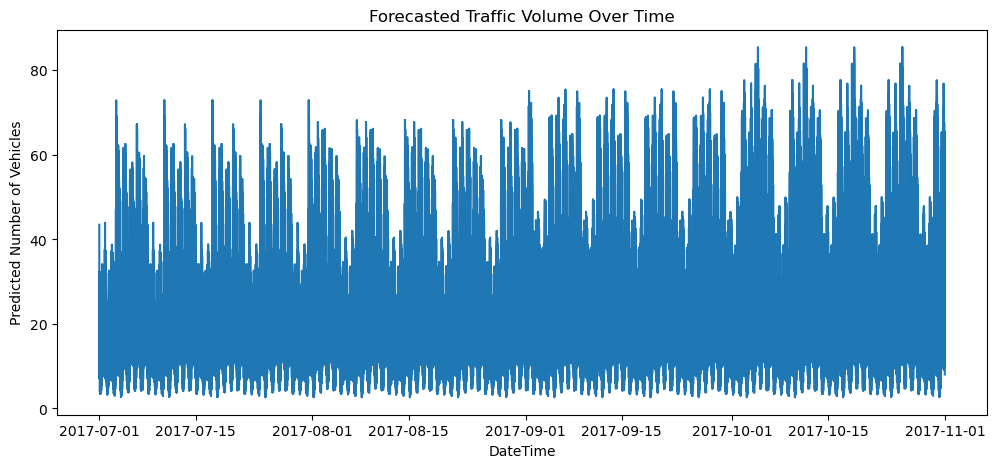

In [48]:
# Plotting predicted traffic over time
plt.figure(figsize=(12,5))
plt.plot(test['DateTime'], test['Predicted_Vehicles'])
plt.title("Forecasted Traffic Volume Over Time")
plt.xlabel("DateTime")
plt.ylabel("Predicted Number of Vehicles")
plt.show()

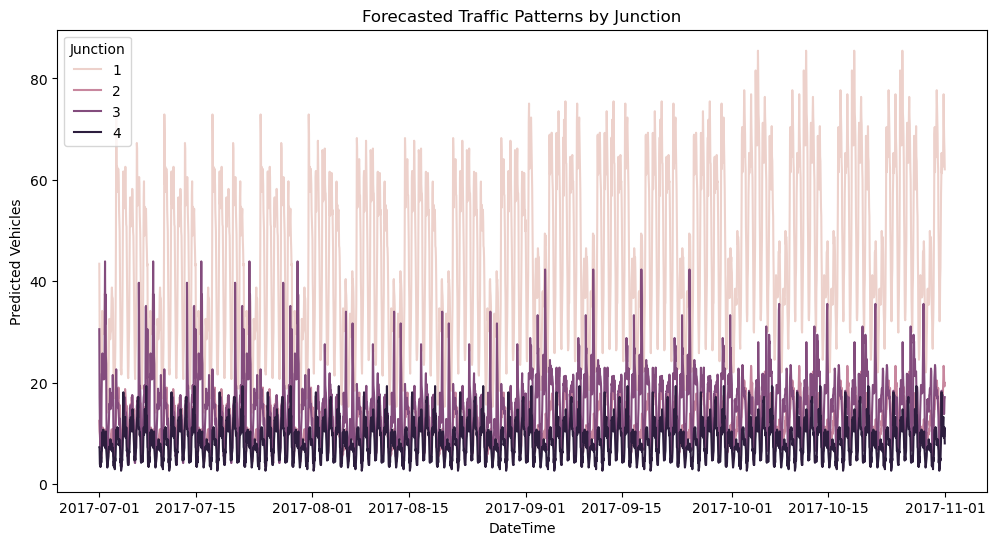

In [49]:
# Forecasted traffic by junction
plt.figure(figsize=(12,6))
sns.lineplot(data=test, x='DateTime', y='Predicted_Vehicles', hue='Junction')
plt.title("Forecasted Traffic Patterns by Junction")
plt.xlabel("DateTime")
plt.ylabel("Predicted Vehicles")
plt.show()

In [50]:
#This project analyzed historical traffic data from four city junctions to understand temporal traffic patterns and forecast future traffic volumes. 
#Time-based features were extracted to capture hourly, daily, and weekly variations. 
#Linear Regression was used as a baseline model, while Random Forest Regressor demonstrated superior performance due to its ability to model non-linear relationships. 
#The forecasting results provide useful insights that can assist government authorities in proactive traffic management and smart city infrastructure planning.

In [51]:
#Limitations:

#->The model relies only on historical traffic and time-based features.
#->External factors such as weather, accidents, road construction, and public events were not included.
#->Real-time traffic conditions were not considered.